# 策略四：资金费率套利（加密货币）

## 核心思路

永续合约市场每8小时在多空双方之间收取一次**资金费率**。当资金费率持续为正时（多头付费给空头），可以构建 Delta 中性头寸收取这笔费用：

- **买入现货 BTC**（获得多头敞口）
- **做空 BTC 永续合约**（对冲价格风险）
- **持续收取空头方的资金费**

两腿合计 Delta ≈ 0，主要收益来自资金费率，与 BTC 价格涨跌无关。

## 交易规则

- **入场**：7日滚动平均资金费率 > 0.01%（约合年化 10.95%）
- **离场**：7日滚动平均资金费率 < 0.005%
- **成本**：5% 年化借贷成本 + 4 bps 开平仓手续费

## 风险

- 基差风险（现货与永续价差波动）
- 流动性风险（资金费率突然反转）
- 交易所风险

## 数据

- 资金费率：Binance 公开 API（`fapi.binance.com/fapi/v1/fundingRate`），每8小时一次，2020年至今
- BTC 现货价格：`yfinance`，用于头寸估值

In [1]:
import pandas as pd
import numpy as np
import requests
import time
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

In [2]:
# ── 从 Binance 公开 API 下载 BTC 资金费率历史 ─────────────
def fetch_binance_funding_rate(symbol='BTCUSDT', start_ms=None, end_ms=None, limit=1000):
    """从 Binance Futures 公开 API 分页获取历史资金费率。"""
    url      = 'https://fapi.binance.com/fapi/v1/fundingRate'
    all_data = []
    params   = {'symbol': symbol, 'limit': limit}
    if start_ms: params['startTime'] = start_ms
    if end_ms:   params['endTime']   = end_ms

    cursor = start_ms
    while True:
        if cursor: params['startTime'] = cursor
        try:
            r = requests.get(url, params=params, timeout=10)
            r.raise_for_status()
            batch = r.json()
        except Exception as e:
            print(f"API 请求失败：{e}")
            break
        if not batch:
            break
        all_data.extend(batch)
        last_ts = batch[-1]['fundingTime']
        if len(batch) < limit:
            break
        cursor = last_ts + 1
        time.sleep(0.1)
    return all_data

START_DATE = '2020-01-01'
start_ms   = int(datetime.strptime(START_DATE, '%Y-%m-%d').replace(tzinfo=timezone.utc).timestamp() * 1000)

print("正在从 Binance 下载 BTC 历史资金费率...")
raw_data = fetch_binance_funding_rate('BTCUSDT', start_ms=start_ms)
print(f"获取到 {len(raw_data)} 条资金费率记录")

正在从 Binance 下载 BTC 历史资金费率...


API 请求失败：451 Client Error:  for url: https://fapi.binance.com/fapi/v1/fundingRate?symbol=BTCUSDT&limit=1000&startTime=1577836800000
获取到 0 条资金费率记录


In [3]:
# ── 解析与清洗资金费率数据 ──────────────────────────────────
if len(raw_data) > 0:
    fr_df = pd.DataFrame(raw_data)
    fr_df['datetime']     = pd.to_datetime(fr_df['fundingTime'], unit='ms', utc=True)
    fr_df['funding_rate'] = fr_df['fundingRate'].astype(float)
    fr_df = fr_df.set_index('datetime').sort_index()
    fr_df = fr_df[['funding_rate']]
else:
    # 网络不通时的 Fallback：用合理参数生成模拟数据
    print("API 不可用，使用模拟数据演示（均值约0.01%/8h，符合历史均值）")
    idx = pd.date_range('2020-01-01', '2024-12-31', freq='8h', tz='UTC')
    np.random.seed(42)
    # BTC 资金费率历史均值约 0.01%，牛市偏高，熊市偏低
    trend = np.linspace(0.00015, 0.00005, len(idx))  # 模拟从牛市高位降至低位
    noise = 0.0003 * np.random.randn(len(idx))
    fr    = np.clip(trend + noise, -0.001, 0.003)
    fr_df = pd.DataFrame({'funding_rate': fr}, index=idx)

# 年化换算：每8小时结算一次，每天3次，全年365天
fr_df['ann_rate'] = fr_df['funding_rate'] * 3 * 365

print(f"\n资金费率统计：")
print(f"  8小时均值       : {fr_df['funding_rate'].mean()*100:.4f}%")
print(f"  8小时中位数     : {fr_df['funding_rate'].median()*100:.4f}%")
print(f"  年化均值        : {fr_df['ann_rate'].mean()*100:.2f}%")
print(f"  正资金费率占比  : {(fr_df['funding_rate'] > 0).mean()*100:.1f}%")
fr_df.head(5)

API 不可用，使用模拟数据演示（均值约0.01%/8h，符合历史均值）

资金费率统计：
  8小时均值       : 0.0101%
  8小时中位数     : 0.0103%
  年化均值        : 11.01%
  正资金费率占比  : 63.1%


,funding_rate,ann_rate
2020-01-01 00:00:00+00:00,0.000299,0.327421
2020-01-01 08:00:00+00:00,0.000109,0.118810
2020-01-01 16:00:00+00:00,0.000344,0.376976
2020-01-02 00:00:00+00:00,0.000607,0.664505
2020-01-02 08:00:00+00:00,0.000080,0.087251


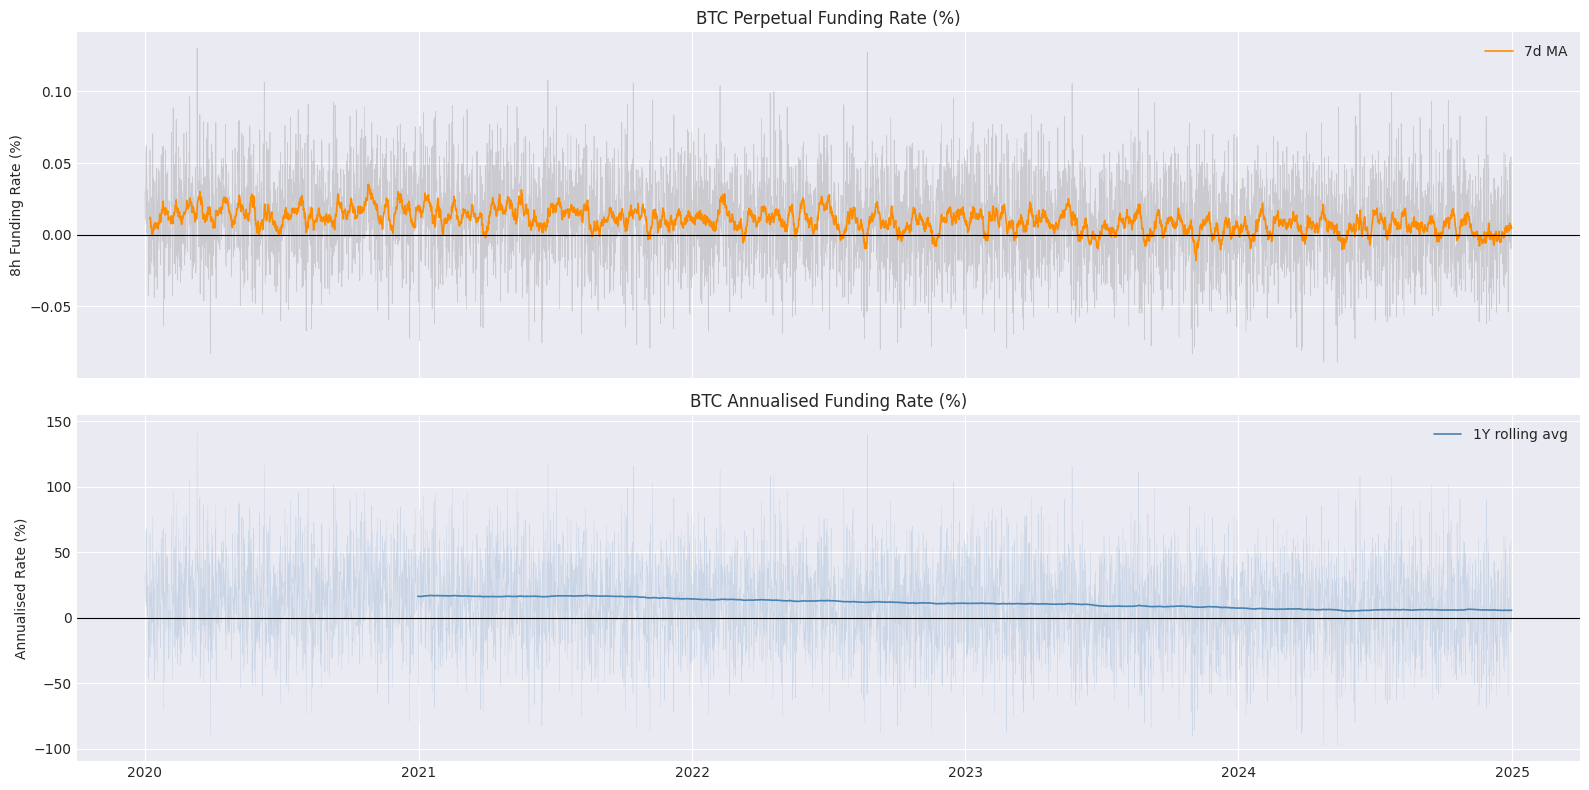

In [4]:
# --- Visualise funding rate history ---
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# 7-day rolling average funding rate
roll_fr = fr_df['funding_rate'].rolling(21).mean()  # 21 * 8h = 7 days
axes[0].plot(fr_df.index, fr_df['funding_rate'] * 100, alpha=0.3, color='grey', lw=0.5)
axes[0].plot(roll_fr.index, roll_fr * 100, color='darkorange', lw=1.2, label='7d MA')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('BTC Perpetual Funding Rate (%)', fontsize=12)
axes[0].set_ylabel('8h Funding Rate (%)')
axes[0].legend()

# Annualised running average
cum_ann = fr_df['ann_rate'].rolling(365 * 3).mean() * 100
axes[1].plot(fr_df.index, fr_df['ann_rate'] * 100, alpha=0.2, color='steelblue', lw=0.3)
axes[1].plot(cum_ann.index, cum_ann, color='steelblue', lw=1.2, label='1Y rolling avg')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('BTC Annualised Funding Rate (%)', fontsize=12)
axes[1].set_ylabel('Annualised Rate (%)')
axes[1].legend()
plt.tight_layout()
plt.show()

In [5]:
# --- Fetch BTC spot price (for sizing & context) ---
import yfinance as yf
btc_raw = yf.download('BTC-USD', start='2020-01-01', end='2024-12-31',
                      auto_adjust=True, progress=False)['Close']
# yfinance >= 1.x: squeeze DataFrame to Series for single ticker
btc = btc_raw.squeeze() if isinstance(btc_raw, pd.DataFrame) else btc_raw
btc_8h = btc.resample('8h').last().ffill()
btc_8h.index = btc_8h.index.tz_localize('UTC')

# Align with funding data
btc_8h_named = btc_8h.rename('btc_price')
merged = fr_df.join(btc_8h_named, how='left').ffill().dropna()
print(f"Combined dataset: {len(merged)} rows")
merged.head(3)

Combined dataset: 5479 rows


,funding_rate,ann_rate,btc_price
2020-01-01 00:00:00+00:00,0.000299,0.327421,7200.174316
2020-01-01 08:00:00+00:00,0.000109,0.118810,7200.174316
2020-01-01 16:00:00+00:00,0.000344,0.376976,7200.174316


In [6]:
# ── 资金费率套利回测 ──────────────────────────────────────
# 规则：
#   入场：7日滚动平均资金费率 > ENTRY_THRESHOLD
#   离场：7日滚动平均资金费率 < EXIT_THRESHOLD
#   P&L：资金费收入 - 借贷成本 - 手续费（现货腿 Delta 被对冲，价格变动抵消）

ENTRY_THRESHOLD = 0.0001   # 入场阈值：0.01%/8h ≈ 年化 10.95%
EXIT_THRESHOLD  = 0.00005  # 离场阈值：0.005%/8h
BORROW_COST_ANN = 0.05     # 年化借贷成本：5%（现货融资成本）
ENTRY_FEE       = 0.0004   # 开/平仓手续费：4 bps（两腿合计 8 bps）

merged['roll_fr'] = merged['funding_rate'].rolling(21).mean()  # 7日 = 21个8小时周期

# 生成持仓信号
pos        = np.zeros(len(merged))
current    = 0
entry_fees = np.zeros(len(merged))

for i in range(21, len(merged)):
    roll = merged['roll_fr'].iloc[i]
    if np.isnan(roll): continue
    if current == 0 and roll > ENTRY_THRESHOLD:
        current = 1
        entry_fees[i] = ENTRY_FEE  # 建仓手续费
    elif current == 1 and roll < EXIT_THRESHOLD:
        current = 0
        entry_fees[i] = ENTRY_FEE  # 平仓手续费
    pos[i] = current

merged['pos']         = pos
merged['entry_fees']  = entry_fees

# 每个8小时周期的 P&L：
#   - 现货腿 Delta = 0（被永续合约完全对冲）
#   - 资金费收入：空头永续合约收取正向资金费
#   - 借贷成本：持有现货的融资成本（每8小时摊销）
borrow_per_period = BORROW_COST_ANN / (365 * 3)

merged['funding_income'] = merged['pos'].shift(1) * merged['funding_rate']
merged['borrow_cost']    = merged['pos'].shift(1) * borrow_per_period
merged['net_pnl_8h']     = merged['funding_income'] - merged['borrow_cost'] - merged['entry_fees']
merged['cum_pnl']        = merged['net_pnl_8h'].cumsum() * 100  # 转为百分比

# 绩效汇总
total_income  = merged['funding_income'].sum() * 100
total_borrow  = merged['borrow_cost'].sum() * 100
total_fees    = merged['entry_fees'].sum() * 100
net_total     = merged['net_pnl_8h'].sum() * 100
exposure_days = (merged['pos'] > 0).sum() / 3  # 持仓天数

print(f"{'='*50}")
print(f"  资金费率套利回测结果")
print(f"{'='*50}")
print(f"  毛资金费收入        : {total_income:.2f}%")
print(f"  借贷成本            : {total_borrow:.2f}%")
print(f"  交易手续费          : {total_fees:.2f}%")
print(f"  净 P&L（名义本金%） : {net_total:.2f}%")
print(f"  持仓天数            : {exposure_days:.0f} / {len(merged)/3:.0f}")
print(f"  平均年化收益率      : {net_total / (len(merged)/3/365):.2f}% p.a.")

  资金费率套利回测结果
  毛资金费收入        : 40.15%
  借贷成本            : 15.86%
  交易手续费          : 6.24%
  净 P&L（名义本金%） : 18.04%
  持仓天数            : 1158 / 1826
  平均年化收益率      : 3.61% p.a.


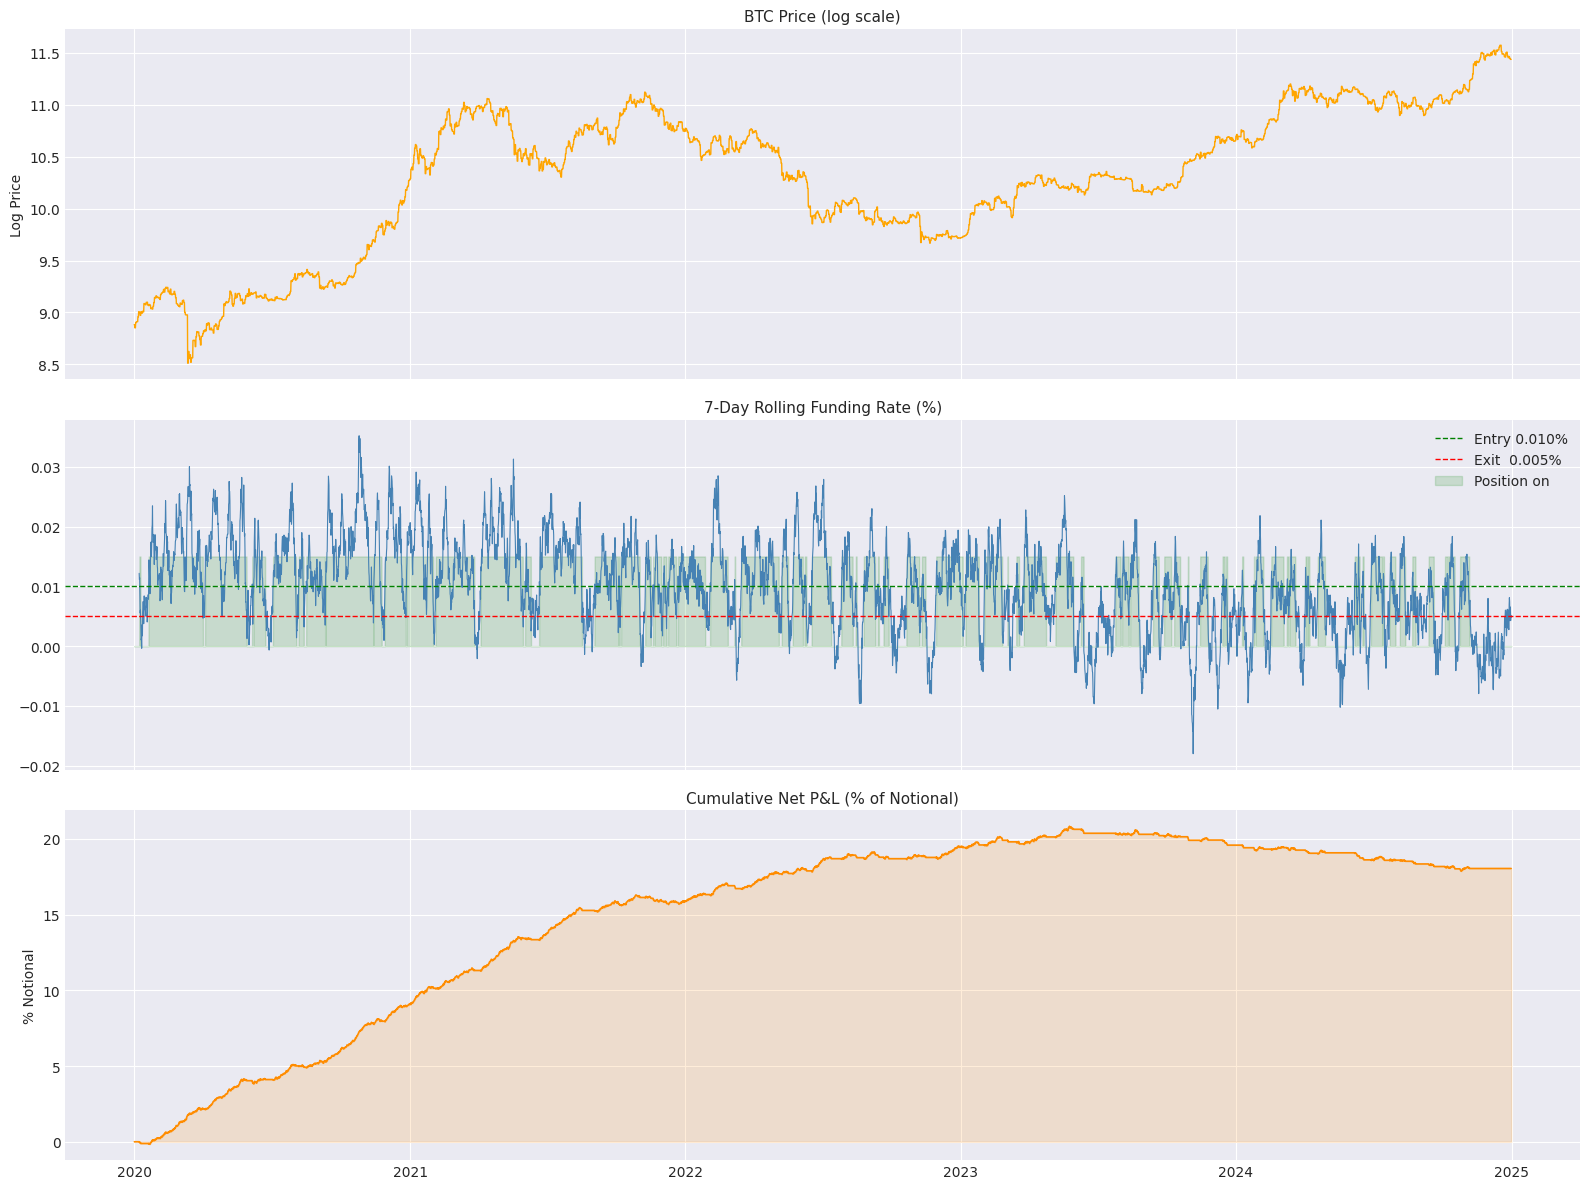

In [7]:
# --- Plot results ---
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(merged.index, np.log(merged['btc_price']), color='orange', lw=1)
axes[0].set_title('BTC Price (log scale)', fontsize=11)
axes[0].set_ylabel('Log Price')

axes[1].plot(merged.index, merged['roll_fr'] * 100, color='steelblue', lw=0.8)
axes[1].axhline(ENTRY_THRESHOLD * 100, color='green', ls='--', lw=1, label=f'Entry {ENTRY_THRESHOLD*100:.3f}%')
axes[1].axhline(EXIT_THRESHOLD * 100,  color='red',   ls='--', lw=1, label=f'Exit  {EXIT_THRESHOLD*100:.3f}%')
axes[1].fill_between(merged.index, merged['pos'] * ENTRY_THRESHOLD * 100 * 1.5,
                     alpha=0.15, color='green', label='Position on')
axes[1].set_title('7-Day Rolling Funding Rate (%)', fontsize=11)
axes[1].legend()

axes[2].plot(merged.index, merged['cum_pnl'], color='darkorange', lw=1.2)
axes[2].fill_between(merged.index, merged['cum_pnl'], alpha=0.15, color='darkorange')
axes[2].set_title('Cumulative Net P&L (% of Notional)', fontsize=11)
axes[2].set_ylabel('% Notional')

plt.tight_layout()
plt.savefig('../assets/funding_arb_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [8]:
# --- Sensitivity: different entry thresholds ---
thresholds = [0.00005, 0.0001, 0.00015, 0.0002, 0.00025, 0.0003]
results_table = []

for thresh in thresholds:
    pos_t = np.zeros(len(merged))
    cur = 0
    fees_t = np.zeros(len(merged))
    for i in range(21, len(merged)):
        roll = merged['roll_fr'].iloc[i]
        if np.isnan(roll): continue
        if cur == 0 and roll > thresh:
            cur = 1; fees_t[i] = ENTRY_FEE
        elif cur == 1 and roll < thresh * 0.5:
            cur = 0; fees_t[i] = ENTRY_FEE
        pos_t[i] = cur
    fi = (pd.Series(pos_t).shift(1).fillna(0) * merged['funding_rate'].values).sum()
    bc = (pd.Series(pos_t).shift(1).fillna(0) * borrow_per_period).sum()
    net = (fi - bc - fees_t.sum()) * 100
    days_in = (pos_t > 0).sum() / 3
    results_table.append({'threshold_%': thresh*100, 'net_pnl_%': round(net, 2),
                           'days_in_market': round(days_in)})

print(pd.DataFrame(results_table).set_index('threshold_%').to_string())

             net_pnl_%  days_in_market
threshold_%                           
0.005            21.29            1477
0.010            18.04            1158
0.015            13.16             808
0.020             6.89             401
0.025             2.59             187
0.030             0.42              28
